# **<p align="center"> Xi 1 Angle of Residues Analysis </p>**

## <ins> Description </ins>
### Explanation

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


In [8]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator
# General Purpose Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
# Molecular Libraries
import gemmi 
# from rdkit import Chem
# import parasail
# Local Libraries
from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats,  get_res_CoM , get_atom_coord
from xaidar.data.molecModels import flatten_pdb, createPDB, clear_empty
from xaidar.data.molecModels import sele_pdb, sele_Lig, sele_AA, sele_chain_name

In [9]:
# Test python objs
test_pdb_path = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb")
test_pdb = loadPDB(test_pdb_path)
test_prot = sele_pdb( test_pdb, sele_AA)
test_prot_mon = sele_pdb( test_prot, sele_chain_name, chain_name = "A")
test_lig = sele_pdb( test_pdb, sele_Lig)
test_chain = flatten_pdb( test_prot_mon, "chain" )
test_res = test_chain[0][0] 
test_atom =  test_res[0]

---


In [107]:
angles_dir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/xi1anlges")
with open( angles_dir.joinpath("lst_prots_dihedral_angles.pkl"), "rb") as f:
    lst_prots_dihedral_angles = pkl.load(f)
    
print( len(lst_prots_dihedral_angles) )
print( len(lst_prots_dihedral_angles[0]) )
print( set( [ len(prot_lst) for prot_lst in lst_prots_dihedral_angles] ) )
print(lst_prots_dihedral_angles[0][-10:])
lst_prots_dihedral_angles[0].pop(128)
lst_prots_dihedral_angles[0][-10:]

467
138
{138}
['ALA', -3.0701575825514698, -1.222330487299842, -1.1151297049113678, 1.0892627585753167, -1.0213619405533372, -1.0275323275381019, 1.1333722430645308, -1.41986933826457, -1.3181094623192056]


[-0.871405495860652,
 -3.0701575825514698,
 -1.222330487299842,
 -1.1151297049113678,
 1.0892627585753167,
 -1.0213619405533372,
 -1.0275323275381019,
 1.1333722430645308,
 -1.41986933826457,
 -1.3181094623192056]

In [108]:
PAG_sites = [1, 2, 6, 16, 22, 40, 42, 47, 54, 66, 72, 79, 84, 85, 94, 96, 100, 101, 104, 105, 112, 115, 120, 121, 123, 126, 128]
not_PAG_sites = [ idx for idx in range(1, 138) if idx not in PAG_sites ]
DSR_mut_prots =  [46, 52, 64, 95, 98]
DSR_sites = [70,61,50]
not_DSR_sites = [ idx for idx in range(1, 138) if idx not in DSR_sites ]

In [128]:
arr_angle_diffs = np.zeros( (len(lst_prots_dihedral_angles), len(lst_prots_dihedral_angles) ) )
from copy import deepcopy
lst_prots_i = deepcopy(lst_prots_dihedral_angles)
lst_prots_j = deepcopy(lst_prots_dihedral_angles)
for i, prot_I in enumerate( lst_prots_i ):
    for j, prot_J in enumerate( lst_prots_j):
        prot_i = deepcopy(prot_I)
        prot_j = deepcopy(prot_J)
        if i >= j:
            remove_sites = PAG_sites
            if i in DSR_mut_prots or j in DSR_mut_prots:
                remove_sites = remove_sites + DSR_sites
            remove_sites = sorted(remove_sites, reverse=True)
            for rm_site in remove_sites:
                prot_i.pop(rm_site)
                prot_j.pop(rm_site)
            
            angle_diffs = []
            for res_angle_i, res_angle_j in zip(prot_i, prot_j):
                if isinstance(res_angle_i, float ) and isinstance(res_angle_j, float ):
                    angle_diffs.append( np.abs(res_angle_i - res_angle_j) )
                elif isinstance(res_angle_i, tuple ) and isinstance(res_angle_j, float ):
                    angles = np.array( res_angle_i[0])
                    occ = np.array( res_angle_i[1] )
                    res_angle_j = np.float64( res_angle_j )
                    angle_diffs.append( np.sum( np.abs(angles - res_angle_j) * occ ) )
                elif isinstance(res_angle_i, float ) and isinstance(res_angle_j, tuple ):
                    angles = np.array( res_angle_j[0])
                    occ = np.array( res_angle_j[1] )
                    res_angle_i = np.float64( res_angle_i )
                    angle_diffs.append( np.sum( np.abs(angles - res_angle_i) * occ ) )                    
                elif isinstance(res_angle_i, tuple ) and isinstance(res_angle_j, tuple ):
                    angles_i = np.array( res_angle_i[0])
                    occ_i = np.array( res_angle_i[1] )
                    angles_j = np.array( res_angle_j[0])
                    occ_j = np.array( res_angle_j[1] )
                    angles = (angles_i[np.newaxis, :]  - angles_j[:, np.newaxis] )
                    occs = (occ_i[np.newaxis, :]  * occ_j[:, np.newaxis] )
                    angle_diffs.append( np.sum( np.abs(angles) * occs ) )                
                else:
                    raise ValueError("Unexpected angle value. Check the residue for more details.")
           
    
            arr_angle_diffs[i, j] = np.sum(angle_diffs)



In [129]:
for i, prot_I in enumerate( lst_prots_i ):
    for j, prot_J in enumerate( lst_prots_j):
        if i < j: arr_angle_diffs[i, j] = arr_angle_diffs[j, i]

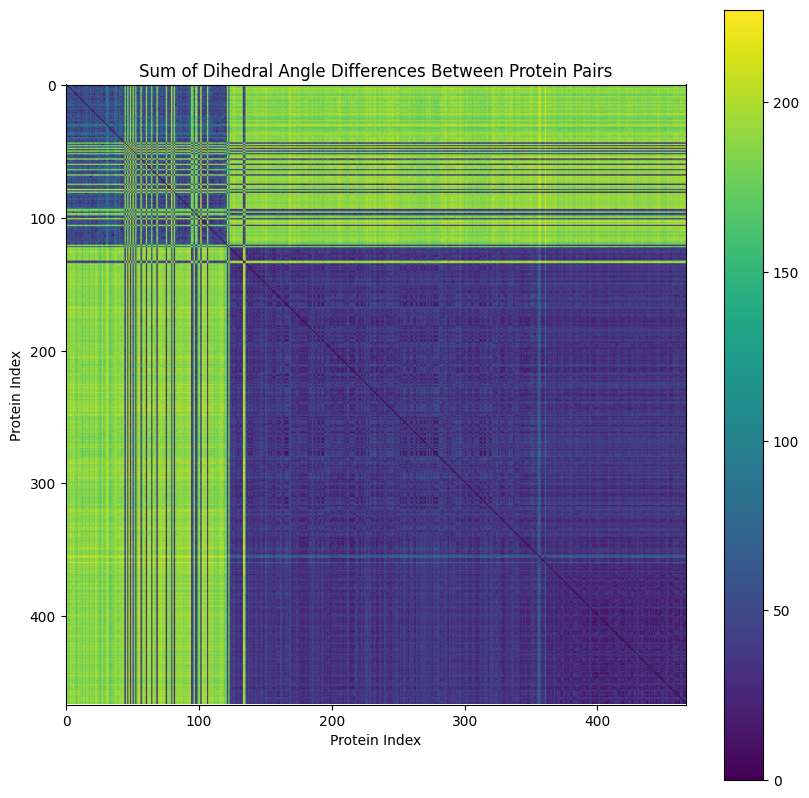

In [130]:
fig = plt.figure(figsize=(10,10))
plt.imshow(arr_angle_diffs, cmap="viridis")
plt.colorbar()
plt.title("Sum of Dihedral Angle Differences Between Protein Pairs")
plt.xlabel("Protein Index")
plt.ylabel("Protein Index")
plt.show()

In [125]:
for i in [1,2,3,4]:
    for j in [-1,-2,-3,-4]:
        print(i,j)

1 -1
1 -2
1 -3
1 -4
2 -1
2 -2
2 -3
2 -4
3 -1
3 -2
3 -3
3 -4
4 -1
4 -2
4 -3
4 -4


In [ ]:



angles_i = np.array( [10,15])
occ_i = np.array( [0.7, 0.3]  )


angles_j = np.array( [ 12, 18] )
occ_j = np.array( [0.2, 0.8]  )

angles = (angles_i[np.newaxis, :]  - angles_j[:, np.newaxis] )
print(angles)

[[-2  3]
 [-8 -3]]


In [85]:
occs = (occ_i[np.newaxis, :]  * occ_j[:, np.newaxis] )
print(occs)
print(np.sum(occs))

[[0.14 0.06]
 [0.56 0.24]]
0.9999999999999999


In [86]:
np.abs(angles * occs)

array([[0.28, 0.18],
       [4.48, 0.72]])